# 04 - Глубокий EDA (утечки, drift, сегменты)

Ноутбук выполняет расширенный EDA для страхового кейса с практическим ML-фокусом:

- screening рисков утечки таргета,
- диагностика временного drift,
- анализ риска по сегментам,
- actionable keep/review/drop для признаков.

In [1]:
# 00. Setup
from __future__ import annotations

import json
import re
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
np.random.seed(42)


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "configs" / "default.json").exists() and (p / "src").exists():
            return p
    return start


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"

import sys

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from risk_case.data.policy_aggregation import aggregate_to_policy_level
from risk_case.eda import EDAConfig, run_eda

DEFAULT_CFG_PATH = PROJECT_ROOT / "configs" / "default.json"
EDA_CFG_PATH = PROJECT_ROOT / "configs" / "eda.json"

default_cfg = json.loads(DEFAULT_CFG_PATH.read_text(encoding="utf-8"))
train_path = PROJECT_ROOT / default_cfg["paths"]["train_csv"]
test_path = PROJECT_ROOT / default_cfg["paths"]["test_csv"]

DEEP_OUT_DIR = PROJECT_ROOT / "artifacts" / "eda" / "deep"
DEEP_TABLES_DIR = DEEP_OUT_DIR / "tables"
DEEP_FIGS_DIR = DEEP_OUT_DIR / "figures"
REPORTS_DIR = PROJECT_ROOT / "reports"

for p in [DEEP_OUT_DIR, DEEP_TABLES_DIR, DEEP_FIGS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

TOP_N_PSI = 30
TOP_N_PLOTS = 20
MAX_NUMERIC_FEATURES_FOR_CORR = 250

print("PROJECT_ROOT:", PROJECT_ROOT)
print("train_path:", train_path)
print("test_path:", test_path)
print("deep_out:", DEEP_OUT_DIR)

PROJECT_ROOT: C:\Users\Admin\Desktop\Риск кейс чемпоинат
train_path: C:\Users\Admin\Desktop\Риск кейс чемпоинат\final_dataset\final_dataset\train.csv
test_path: C:\Users\Admin\Desktop\Риск кейс чемпоинат\final_dataset\final_dataset\test_final.csv
deep_out: C:\Users\Admin\Desktop\Риск кейс чемпоинат\artifacts\eda\deep


## 1. Запуск базового EDA и загрузка данных

In [2]:
# 01. Reuse base EDA artifacts and load train/test
eda_cfg = EDAConfig.from_json(EDA_CFG_PATH)
base_eda_result = run_eda(config=eda_cfg, project_root=PROJECT_ROOT)
print(json.dumps(base_eda_result, ensure_ascii=False, indent=2))

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
policy_df = aggregate_to_policy_level(train_df, contract_col="contract_number")

print("raw train shape:", train_df.shape)
print("raw test shape :", test_df.shape)
print("policy shape   :", policy_df.shape)

C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


{
  "status": "ok",
  "output_dir": "C:\\Users\\Admin\\Desktop\\Риск кейс чемпоинат\\artifacts\\eda",
  "summary_path": "C:\\Users\\Admin\\Desktop\\Риск кейс чемпоинат\\reports\\eda_summary.md",
  "profile_path": "C:\\Users\\Admin\\Desktop\\Риск кейс чемпоинат\\artifacts\\eda\\metadata\\eda_profile.json",
  "feature_selection_report_path": "C:\\Users\\Admin\\Desktop\\Риск кейс чемпоинат\\reports\\feature_selection_report.md",
  "feature_selection_summary_path": "C:\\Users\\Admin\\Desktop\\Риск кейс чемпоинат\\artifacts\\eda\\feature_selection\\feature_selection_summary.json"
}


C:\Users\Admin\AppData\Local\Temp\ipykernel_12636\1482377330.py:6: DtypeWarning: Columns (16,28) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(train_path)


C:\Users\Admin\AppData\Local\Temp\ipykernel_12636\1482377330.py:7: DtypeWarning: Columns (13,25) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv(test_path)


raw train shape: (569508, 159)
raw test shape : (244073, 156)
policy shape   : (180635, 156)


## 2. Обзор датасета и проверки консистентности

In [3]:
# 02. Schema and duplicate checks
if "operation_date" in train_df.columns:
    train_df["operation_date"] = pd.to_datetime(train_df["operation_date"], errors="coerce")
if "operation_date" in test_df.columns:
    test_df["operation_date"] = pd.to_datetime(test_df["operation_date"], errors="coerce")

train_cols = set(train_df.columns)
test_cols = set(test_df.columns)
train_only_cols = sorted(train_cols - test_cols)
test_only_cols = sorted(test_cols - train_cols)
common_cols = sorted(train_cols & test_cols)

schema_diff = pd.DataFrame(
    {
        "train_only_columns": pd.Series(train_only_cols, dtype="object"),
        "test_only_columns": pd.Series(test_only_cols, dtype="object"),
    }
)
schema_diff_path = DEEP_TABLES_DIR / "schema_diff_deep.csv"
schema_diff.to_csv(schema_diff_path, index=False)

id_checks = {}
if "unique_id" in train_df.columns:
    id_checks["train_unique_id_duplicates"] = int(train_df["unique_id"].duplicated().sum())
if "unique_id" in test_df.columns:
    id_checks["test_unique_id_duplicates"] = int(test_df["unique_id"].duplicated().sum())
if {"contract_number", "operation_date"}.issubset(train_df.columns):
    id_checks["train_dup_contract_date"] = int(
        train_df.duplicated(subset=["contract_number", "operation_date"]).sum()
    )

print("common columns:", len(common_cols))
print("train-only columns:", len(train_only_cols))
print("test-only columns:", len(test_only_cols))
print("duplicate checks:", id_checks)
print("schema diff saved:", schema_diff_path)

pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "train_cols",
            "test_rows",
            "test_cols",
            "policy_rows",
            "policy_cols",
        ],
        "value": [
            len(train_df),
            train_df.shape[1],
            len(test_df),
            test_df.shape[1],
            len(policy_df),
            policy_df.shape[1],
        ],
    }
)

common columns: 156
train-only columns: 3
test-only columns: 0
duplicate checks: {'train_unique_id_duplicates': 0, 'test_unique_id_duplicates': 0, 'train_dup_contract_date': 388873}
schema diff saved: C:\Users\Admin\Desktop\Риск кейс чемпоинат\artifacts\eda\deep\tables\schema_diff_deep.csv


,metric,value
0,train_rows,569508
1,train_cols,159
2,test_rows,244073
3,test_cols,156
4,policy_rows,180635
5,policy_cols,156


## 3. Загрузка существующих EDA-артефактов

In [4]:
# 03. Existing artifacts from previous EDA
def read_csv_if_exists(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame()


art_root = PROJECT_ROOT / "artifacts" / "eda"
missing_top20 = read_csv_if_exists(art_root / "tables" / "missing_top20.csv")
leak_watch = read_csv_if_exists(art_root / "tables" / "leakage_watchlist_numeric_corr.csv")
whitelist = read_csv_if_exists(art_root / "feature_selection" / "feature_whitelist.csv")
droplist = read_csv_if_exists(art_root / "feature_selection" / "feature_droplist.csv")

print("missing_top20 rows:", len(missing_top20))
print("leak_watch rows:", len(leak_watch))
print("whitelist rows:", len(whitelist))
print("droplist rows:", len(droplist))

display(missing_top20.head(10))
display(leak_watch.head(10))

missing_top20 rows: 20
leak_watch rows: 119
whitelist rows: 133
droplist rows: 11


,Unnamed: 0,missing_rate
0,SCORE_12_4,0.999540
1,SCORE_12_6,0.999380
2,SCORE_12_5,0.997975
3,SCORE_12_1,0.996892
4,SCORE_12_2,0.996565
5,SCORE_12_3,0.993563
6,claim_cnt,0.980520
7,claim_amount,0.980520
8,SCORE_12_9_1,0.960671
9,SCORE_11_9,0.854380


,feature,abs_corr_with_is_claim,corr_with_is_claim
0,premium_wo_term,0.087872,0.087872
1,premium,0.061874,0.061874
2,age_experience_id,0.023026,-0.023026
3,vehicle_type_id,0.016771,-0.016771
4,SCORE_6_3,0.016419,-0.016419
5,SCORE_11_1,0.016392,0.016392
6,SCORE_7_1,0.016392,-0.016392
7,SCORE_8_3,0.015665,0.015665
8,SCORE_6_2,0.015559,-0.015559
9,region_id,0.015368,-0.015368


## 4. Missingness и диагностика таргета

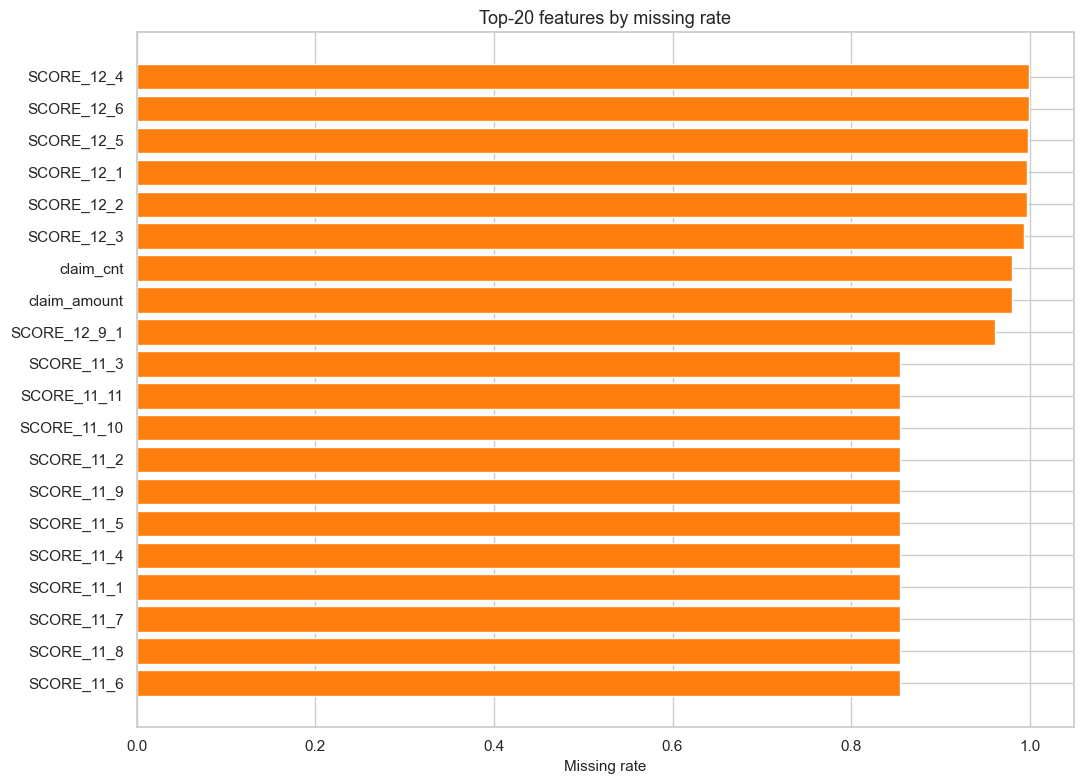

claim rate: 0.01948 | positive claims: 11094


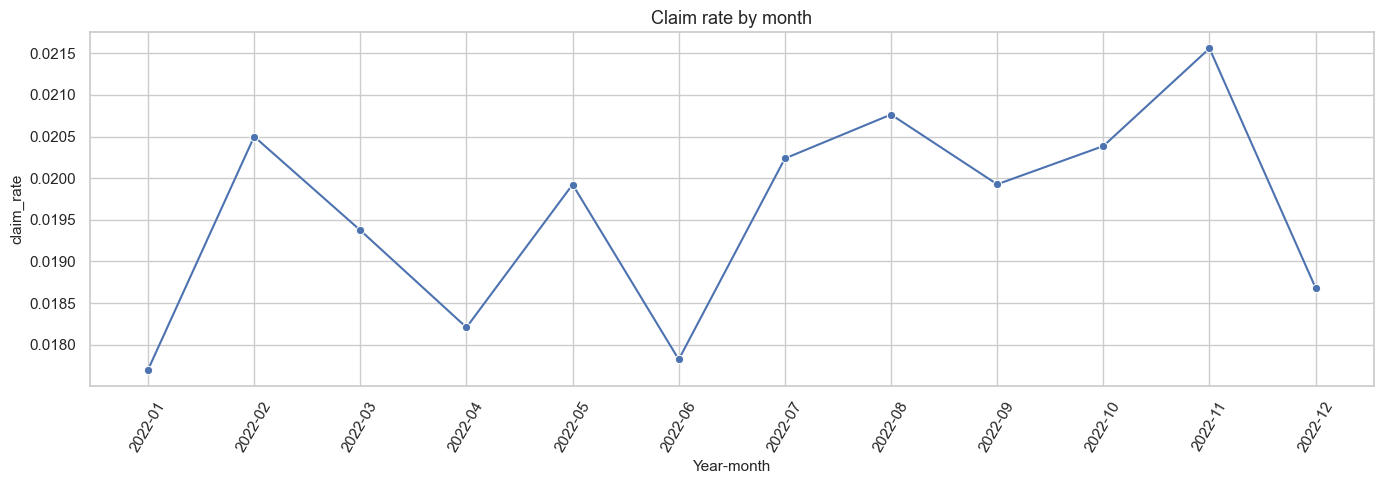

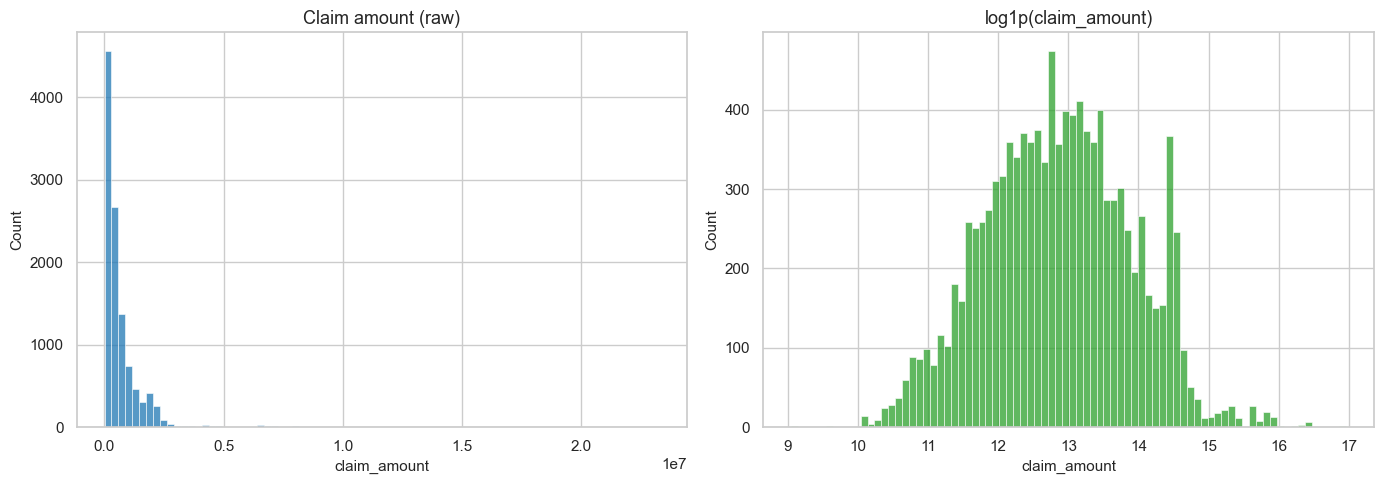

In [5]:
# 04. Missingness + target/severity diagnostics
missing_rate = train_df.isna().mean().sort_values(ascending=False)
missing_df = missing_rate.reset_index()
missing_df.columns = ["feature", "missing_rate"]
missing_df.to_csv(DEEP_TABLES_DIR / "missing_rate_all_features.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 8))
top_missing = missing_df.head(TOP_N_PLOTS).sort_values("missing_rate", ascending=True)
ax.barh(top_missing["feature"], top_missing["missing_rate"], color="tab:orange")
ax.set_title(f"Top-{TOP_N_PLOTS} features by missing rate")
ax.set_xlabel("Missing rate")
plt.tight_layout()
plt.savefig(DEEP_FIGS_DIR / "missing_top_features_deep.png", dpi=160)
plt.show()

for col in ["is_claim", "claim_amount"]:
    if col not in train_df.columns:
        raise ValueError(f"Missing required target column: {col}")

train_df["is_claim"] = pd.to_numeric(train_df["is_claim"], errors="coerce").fillna(0).astype(int)
train_df["claim_amount"] = (
    pd.to_numeric(train_df["claim_amount"], errors="coerce").fillna(0.0).clip(lower=0.0)
)

claim_rate = float(train_df["is_claim"].mean())
pos_count = int((train_df["is_claim"] > 0).sum())
print("claim rate:", round(claim_rate, 6), "| positive claims:", pos_count)

if "operation_date" in train_df.columns and train_df["operation_date"].notna().any():
    tmp = train_df.dropna(subset=["operation_date"]).copy()
    tmp["year_month"] = tmp["operation_date"].dt.to_period("M").astype(str)
    target_by_month = tmp.groupby("year_month", as_index=False).agg(
        claim_rate=("is_claim", "mean"),
        mean_claim_amount=("claim_amount", "mean"),
        rows=("is_claim", "size"),
    )
    target_by_month.to_csv(DEEP_TABLES_DIR / "target_by_month.csv", index=False)

    fig, ax = plt.subplots(figsize=(14, 5))
    sns.lineplot(data=target_by_month, x="year_month", y="claim_rate", marker="o", ax=ax)
    ax.set_title("Claim rate by month")
    ax.set_xlabel("Year-month")
    ax.tick_params(axis="x", rotation=60)
    plt.tight_layout()
    plt.savefig(DEEP_FIGS_DIR / "time_drift_target_rate.png", dpi=160)
    plt.show()

pos_amount = train_df.loc[train_df["is_claim"] > 0, "claim_amount"]
if len(pos_amount) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.histplot(pos_amount, bins=80, ax=axes[0], color="tab:blue")
    axes[0].set_title("Claim amount (raw)")
    sns.histplot(np.log1p(pos_amount), bins=80, ax=axes[1], color="tab:green")
    axes[1].set_title("log1p(claim_amount)")
    plt.tight_layout()
    plt.savefig(DEEP_FIGS_DIR / "claim_amount_distribution_deep.png", dpi=160)
    plt.show()

## 5. Leakage screening (расширенный)

In [6]:
# 05. Leakage screening
TARGET_COLS = {"is_claim", "claim_amount", "claim_cnt"}
FORBIDDEN_COLS = {"unique_id", "driver_iin", "insurer_iin", "car_number", "contract_number"}

pattern_map = {
    "target_name_pattern": re.compile(r"(is_claim|claim_amount|claim_cnt|target|label)", flags=re.I),
    "claim_semantic_pattern": re.compile(r"(claim|loss|payout|paid|reserve|damage)", flags=re.I),
    "id_semantic_pattern": re.compile(r"(iin|id$|_id$|number$)", flags=re.I),
}

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
feature_numeric = [c for c in numeric_cols if c not in TARGET_COLS and c not in FORBIDDEN_COLS]

corr_is_claim = {}
corr_claim_amount = {}
y_claim = train_df["is_claim"].astype(float)
y_amt = pd.to_numeric(train_df["claim_amount"], errors="coerce").fillna(0.0)

for c in feature_numeric[:MAX_NUMERIC_FEATURES_FOR_CORR]:
    x = pd.to_numeric(train_df[c], errors="coerce")
    if x.notna().sum() > 20:
        corr_is_claim[c] = abs(x.corr(y_claim))
        corr_claim_amount[c] = abs(x.corr(y_amt))

rows = []
for col in train_df.columns:
    risk = 0.0
    reasons = []

    if col in TARGET_COLS:
        risk += 100
        reasons.append("exact_target_column")
    if col in FORBIDDEN_COLS:
        risk += 30
        reasons.append("forbidden_identifier_column")

    for rule_name, rgx in pattern_map.items():
        if rgx.search(col):
            if rule_name == "target_name_pattern":
                risk += 35
            elif rule_name == "claim_semantic_pattern":
                risk += 20
            elif rule_name == "id_semantic_pattern":
                risk += 10
            reasons.append(rule_name)

    c1 = float(corr_is_claim.get(col, np.nan))
    c2 = float(corr_claim_amount.get(col, np.nan))
    if not np.isnan(c1):
        if c1 >= 0.35:
            risk += 25
            reasons.append("high_abs_corr_is_claim>=0.35")
        elif c1 >= 0.20:
            risk += 10
            reasons.append("mid_abs_corr_is_claim>=0.20")
    if not np.isnan(c2):
        if c2 >= 0.35:
            risk += 25
            reasons.append("high_abs_corr_claim_amount>=0.35")
        elif c2 >= 0.20:
            risk += 10
            reasons.append("mid_abs_corr_claim_amount>=0.20")

    if col in train_only_cols:
        risk += 15
        reasons.append("train_only_column")

    miss = float(train_df[col].isna().mean())
    if miss > 0.95:
        reasons.append("extremely_sparse")

    if risk >= 90:
        action = "drop"
    elif risk >= 45:
        action = "review"
    else:
        action = "keep"

    rows.append(
        {
            "feature": col,
            "risk_score": risk,
            "abs_corr_is_claim": c1,
            "abs_corr_claim_amount": c2,
            "missing_rate": miss,
            "train_only": int(col in train_only_cols),
            "reasons": ";".join(sorted(set(reasons))),
            "action_recommendation": action,
        }
    )

leakage_rank = pd.DataFrame(rows).sort_values(["risk_score", "feature"], ascending=[False, True])
leakage_rank.to_csv(DEEP_TABLES_DIR / "leakage_risk_rank.csv", index=False)
display(leakage_rank.head(30))

C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,feature,risk_score,abs_corr_is_claim,abs_corr_claim_amount,missing_rate,train_only,reasons,action_recommendation
5,claim_amount,170.0,NaN,NaN,0.000000,1,claim_semantic_pattern;exact_target_column;tar...,drop
6,claim_cnt,170.0,NaN,NaN,0.980520,1,claim_semantic_pattern;exact_target_column;ext...,drop
7,is_claim,170.0,NaN,NaN,0.000000,1,claim_semantic_pattern;exact_target_column;tar...,drop
27,car_number,40.0,NaN,NaN,0.000000,0,forbidden_identifier_column;id_semantic_pattern,keep
1,contract_number,40.0,NaN,NaN,0.000000,0,forbidden_identifier_column;id_semantic_pattern,keep
9,driver_iin,40.0,NaN,NaN,0.001852,0,forbidden_identifier_column;id_semantic_pattern,keep
8,insurer_iin,40.0,NaN,NaN,0.000622,0,forbidden_identifier_column;id_semantic_pattern,keep
0,unique_id,40.0,NaN,NaN,0.000000,0,forbidden_identifier_column;id_semantic_pattern,keep
17,age_experience_id,10.0,0.023026,0.014071,0.000000,0,id_semantic_pattern,keep
14,region_id,10.0,0.015368,0.010390,0.000000,0,id_semantic_pattern,keep


## 6. Временной drift (PSI + categorical shift)

drift windows: 170852 170853


,feature,psi
106,SCORE_9_21,0.105812
102,SCORE_9_17,0.105430
94,SCORE_9_9,0.103938
90,SCORE_9_5,0.102520
98,SCORE_9_13,0.091518
71,SCORE_5_7,0.091281
86,SCORE_9_1,0.089640
65,SCORE_5_1,0.089330
8,ownerkato,0.084454
72,SCORE_5_8,0.083258


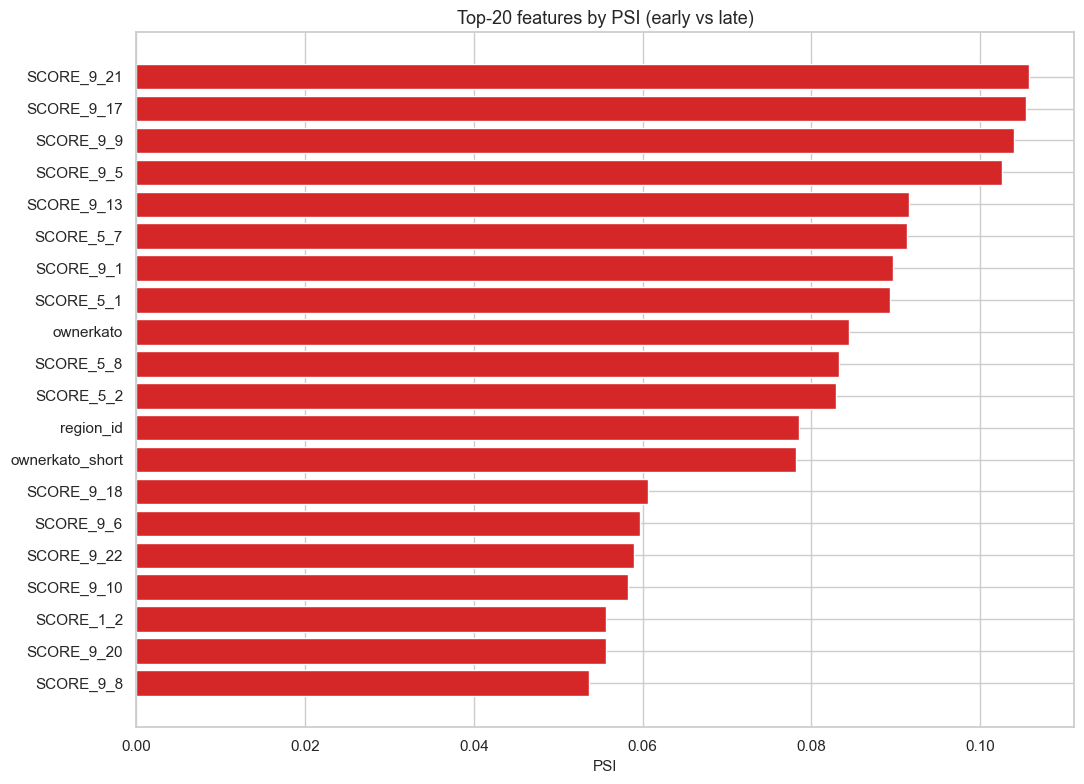

,feature,total_variation_distance,late_unseen_rate_vs_early,early_unique,late_unique
0,unique_id,1.000000,1.000000,170852,170853
1,contract_number,1.000000,1.000000,54669,53064
13,car_number,0.902296,0.869800,55436,53333
2,insurer_iin,0.822361,0.727696,45920,41258
3,driver_iin,0.804381,0.722697,131417,120324
11,model,0.189511,0.054257,5764,5606
6,region_name,0.132872,0.006105,19,22
7,bonus_malus,0.101871,0.096516,15,30
12,mark,0.093879,0.008077,724,713
14,car_year,0.082782,0.000135,92,71


In [7]:
# 06. Drift analysis
def psi_from_arrays(ref: np.ndarray, cur: np.ndarray, bins: int = 10) -> float:
    ref = np.asarray(ref, dtype=float)
    cur = np.asarray(cur, dtype=float)
    ref = ref[~np.isnan(ref)]
    cur = cur[~np.isnan(cur)]
    if len(ref) < 50 or len(cur) < 50:
        return np.nan

    edges = np.quantile(ref, np.linspace(0, 1, bins + 1))
    edges = np.unique(edges)
    if len(edges) < 3:
        return np.nan

    ref_hist, _ = np.histogram(ref, bins=edges)
    cur_hist, _ = np.histogram(cur, bins=edges)
    ref_pct = ref_hist / max(ref_hist.sum(), 1)
    cur_pct = cur_hist / max(cur_hist.sum(), 1)

    eps = 1e-6
    ref_pct = np.clip(ref_pct, eps, 1)
    cur_pct = np.clip(cur_pct, eps, 1)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))


if "operation_date" not in train_df.columns or train_df["operation_date"].notna().sum() == 0:
    raise ValueError("operation_date is required for drift analysis")

sorted_df = train_df.dropna(subset=["operation_date"]).sort_values("operation_date").copy()
n = len(sorted_df)
early_df = sorted_df.iloc[: int(n * 0.30)].copy()
late_df = sorted_df.iloc[int(n * 0.70) :].copy()
print("drift windows:", len(early_df), len(late_df))

drift_numeric_cols = [
    c
    for c in sorted_df.select_dtypes(include=[np.number]).columns
    if c not in TARGET_COLS and c not in FORBIDDEN_COLS
]

psi_rows = []
for c in drift_numeric_cols:
    psi = psi_from_arrays(
        pd.to_numeric(early_df[c], errors="coerce").values,
        pd.to_numeric(late_df[c], errors="coerce").values,
        bins=10,
    )
    psi_rows.append({"feature": c, "psi": psi})

psi_df = pd.DataFrame(psi_rows).dropna().sort_values("psi", ascending=False)
psi_df.to_csv(DEEP_TABLES_DIR / "drift_psi_by_feature.csv", index=False)
display(psi_df.head(TOP_N_PSI))

if len(psi_df) > 0:
    fig, ax = plt.subplots(figsize=(11, 8))
    top_psi = psi_df.head(TOP_N_PLOTS).iloc[::-1]
    ax.barh(top_psi["feature"], top_psi["psi"], color="tab:red")
    ax.set_title(f"Top-{TOP_N_PLOTS} features by PSI (early vs late)")
    ax.set_xlabel("PSI")
    plt.tight_layout()
    plt.savefig(DEEP_FIGS_DIR / "psi_top_features.png", dpi=160)
    plt.show()

cat_cols = [
    c
    for c in sorted_df.columns
    if sorted_df[c].dtype == "object" or str(sorted_df[c].dtype).startswith("string")
]
cat_shift_rows = []
for c in cat_cols:
    ref = early_df[c].astype("string").fillna("__MISSING__")
    cur = late_df[c].astype("string").fillna("__MISSING__")
    ref_freq = ref.value_counts(normalize=True)
    cur_freq = cur.value_counts(normalize=True)
    all_idx = ref_freq.index.union(cur_freq.index)
    tvd = (
        ref_freq.reindex(all_idx, fill_value=0.0) - cur_freq.reindex(all_idx, fill_value=0.0)
    ).abs().sum() / 2
    unseen = float((~cur.isin(ref_freq.index)).mean())
    cat_shift_rows.append(
        {
            "feature": c,
            "total_variation_distance": float(tvd),
            "late_unseen_rate_vs_early": unseen,
            "early_unique": int(ref.nunique(dropna=False)),
            "late_unique": int(cur.nunique(dropna=False)),
        }
    )

cat_shift_df = pd.DataFrame(cat_shift_rows).sort_values(
    ["total_variation_distance", "late_unseen_rate_vs_early"], ascending=False
)
cat_shift_df.to_csv(DEEP_TABLES_DIR / "categorical_shift_summary.csv", index=False)
display(cat_shift_df.head(20))

## 7. Сегментный риск-анализ

,region_name,model,bonus_malus_bin,car_year_bin,count_policies,claim_rate,avg_claim_amount,premium_mean,total_claim_amount,total_premium,lr_proxy
28268,09 Жамбылская область,C230K,12+,<=2005,2,1.000000,1.837800e+06,2415.000000,3675600.0,4830.0,760.993789
27852,09 Жамбылская область,A4,12+,2006-2010,2,1.000000,2.070000e+06,3336.000000,4140000.0,6672.0,620.503597
56753,16 Астана,AVENSIS 2 0 CVT,12+,2006-2010,3,1.000000,2.070000e+06,3565.000000,6210000.0,10695.0,580.645161
56754,16 Астана,AVENSIS 2 0 CVT,9-11,2006-2010,1,1.000000,2.070000e+06,3565.000000,2070000.0,3565.0,580.645161
25431,08 Павлодарская область,DIAMANTE,12+,<=2005,1,1.000000,1.728135e+06,3136.000000,1728135.0,3136.0,551.063457
25432,08 Павлодарская область,DIAMANTE,6-8,<=2005,1,1.000000,1.728135e+06,3136.000000,1728135.0,3136.0,551.063457
29381,09 Жамбылская область,LEGACY,6-8,2006-2010,1,1.000000,4.718400e+06,10115.000000,4718400.0,10115.0,466.475531
7560,01 Алматинская область,PRIMERA P12,12+,<=2005,1,1.000000,2.091505e+06,4802.000000,2091505.0,4802.0,435.548730
73493,18 Туркестанская область,LAND CRUISER 200.,12+,2006-2010,2,1.000000,5.175000e+06,11892.000000,10350000.0,23784.0,435.166498
73497,18 Туркестанская область,LAND CRUISER 200.,<=5,2006-2010,2,1.000000,5.175000e+06,11892.000000,10350000.0,23784.0,435.166498


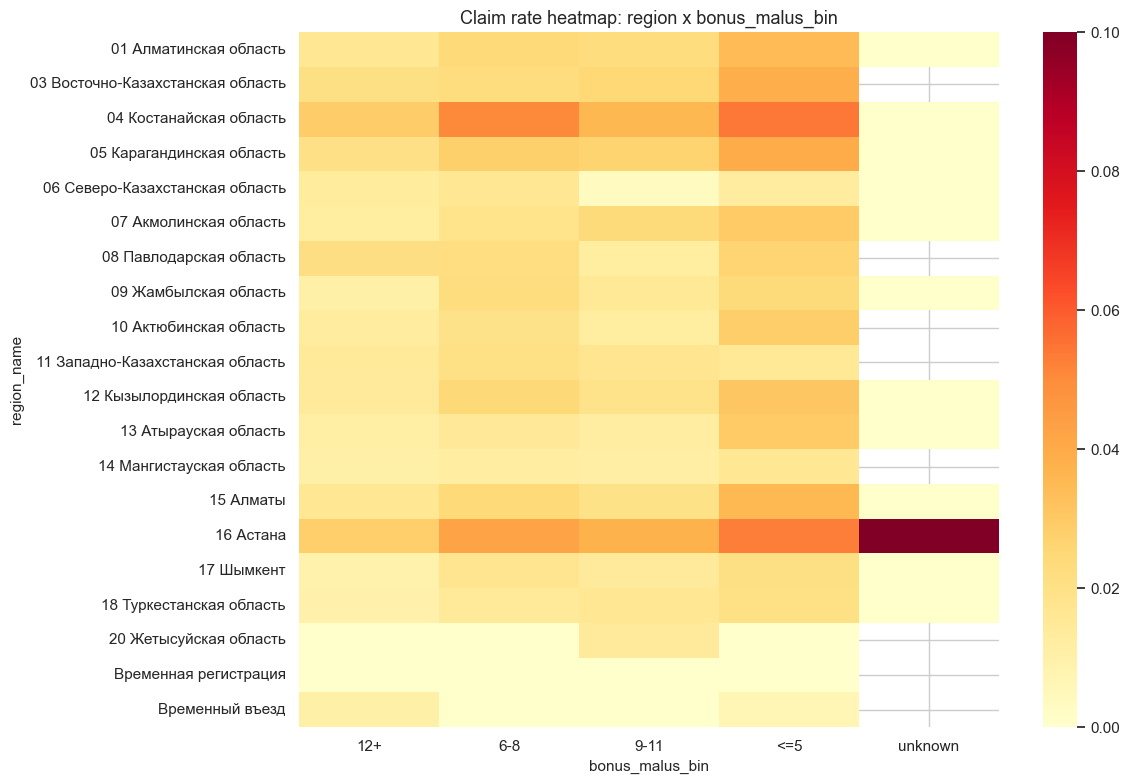

In [8]:
# 07. Segment KPI block
def pick_first_existing(columns: list[str], candidates: list[str]) -> str | None:
    for c in candidates:
        if c in columns:
            return c
    return None


segment_df = train_df.copy()
segment_df["is_claim"] = pd.to_numeric(segment_df["is_claim"], errors="coerce").fillna(0).astype(int)
segment_df["claim_amount"] = (
    pd.to_numeric(segment_df["claim_amount"], errors="coerce").fillna(0.0).clip(lower=0.0)
)

premium_col = pick_first_existing(segment_df.columns.tolist(), ["premium_wo_term", "premium"])
if premium_col is None:
    raise ValueError("premium or premium_wo_term must exist")
segment_df[premium_col] = pd.to_numeric(segment_df[premium_col], errors="coerce").fillna(0.0)

region_col = pick_first_existing(segment_df.columns.tolist(), ["region_name", "ownerkato"])
vehicle_col = pick_first_existing(segment_df.columns.tolist(), ["vehicle_type", "car_type", "model"])
bonus_col = pick_first_existing(segment_df.columns.tolist(), ["bonus_malus"])
car_year_col = pick_first_existing(segment_df.columns.tolist(), ["car_year"])

if bonus_col is not None:
    segment_df[bonus_col] = pd.to_numeric(segment_df[bonus_col], errors="coerce")
    segment_df["bonus_malus_bin"] = pd.cut(
        segment_df[bonus_col],
        bins=[-np.inf, 5, 8, 11, np.inf],
        labels=["<=5", "6-8", "9-11", "12+"],
    )
    segment_df["bonus_malus_bin"] = (
        segment_df["bonus_malus_bin"].astype("string").fillna("unknown").astype(str)
    )
else:
    segment_df["bonus_malus_bin"] = "unknown"

if car_year_col is not None:
    cy = pd.to_numeric(segment_df[car_year_col], errors="coerce")
    segment_df["car_year_bin"] = pd.cut(
        cy,
        bins=[-np.inf, 2005, 2010, 2015, 2020, np.inf],
        labels=["<=2005", "2006-2010", "2011-2015", "2016-2020", "2021+"],
    )
    segment_df["car_year_bin"] = (
        segment_df["car_year_bin"].astype("string").fillna("unknown").astype(str)
    )
else:
    segment_df["car_year_bin"] = "unknown"

segment_keys = [k for k in [region_col, vehicle_col, "bonus_malus_bin", "car_year_bin"] if k is not None]
seg = segment_df.groupby(segment_keys, observed=True, dropna=False, as_index=False).agg(
    count_policies=("is_claim", "size"),
    claim_rate=("is_claim", "mean"),
    avg_claim_amount=("claim_amount", "mean"),
    premium_mean=(premium_col, "mean"),
    total_claim_amount=("claim_amount", "sum"),
    total_premium=(premium_col, "sum"),
)
seg["lr_proxy"] = seg["total_claim_amount"] / seg["total_premium"].replace(0, np.nan)
seg["lr_proxy"] = seg["lr_proxy"].replace([np.inf, -np.inf], np.nan).fillna(0.0)
seg = seg.sort_values(["lr_proxy", "claim_rate", "count_policies"], ascending=[False, False, False])
seg.to_csv(DEEP_TABLES_DIR / "segment_kpi_table.csv", index=False)
display(seg.head(30))

if region_col is not None:
    heat = (
        segment_df.groupby([region_col, "bonus_malus_bin"], observed=True, dropna=False)["is_claim"]
        .mean()
        .reset_index()
        .pivot(index=region_col, columns="bonus_malus_bin", values="is_claim")
    )
    top_regions = segment_df[region_col].astype("string").value_counts().head(20).index
    heat = heat.loc[heat.index.astype("string").isin(top_regions)]

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(heat, cmap="YlOrRd", ax=ax)
    ax.set_title("Claim rate heatmap: region x bonus_malus_bin")
    plt.tight_layout()
    plt.savefig(DEEP_FIGS_DIR / "segment_lr_heatmap.png", dpi=160)
    plt.show()

## 8. Feature action board (keep/review/drop)

In [9]:
# 08. Keep / review / drop board
missing_tbl = missing_df[["feature", "missing_rate"]].copy()
leak_tbl = leakage_rank[["feature", "risk_score", "action_recommendation", "reasons"]].copy()
psi_tbl = psi_df[["feature", "psi"]].copy() if "psi_df" in globals() else pd.DataFrame(columns=["feature", "psi"])

action = missing_tbl.merge(leak_tbl, on="feature", how="outer").merge(psi_tbl, on="feature", how="outer")
action["missing_rate"] = action["missing_rate"].fillna(0.0)
action["risk_score"] = action["risk_score"].fillna(0.0)
action["psi"] = action["psi"].fillna(0.0)
action["action_recommendation"] = action["action_recommendation"].fillna("keep")
action["reasons"] = action["reasons"].fillna("")

def final_action(row: pd.Series) -> str:
    if row["feature"] in TARGET_COLS or row["feature"] in FORBIDDEN_COLS:
        return "drop"
    if row["risk_score"] >= 90:
        return "drop"
    if row["missing_rate"] > 0.95 and row["risk_score"] >= 40:
        return "drop"
    if row["risk_score"] >= 45 or row["psi"] >= 0.25 or row["missing_rate"] > 0.90:
        return "review"
    return "keep"

action["final_action"] = action.apply(final_action, axis=1)
action["priority_score"] = action["risk_score"] + 100 * action["psi"] + 10 * action["missing_rate"]
action = action.sort_values(["final_action", "priority_score"], ascending=[True, False])
action.to_csv(DEEP_TABLES_DIR / "feature_action_board.csv", index=False)

existing_drop = set()
if len(droplist) > 0:
    existing_drop = set(droplist[droplist.columns[0]].astype(str))
existing_keep = set()
if len(whitelist) > 0:
    existing_keep = set(whitelist[whitelist.columns[0]].astype(str))

proposed_drop = set(action.loc[action["final_action"] == "drop", "feature"].astype(str))
proposed_review = set(action.loc[action["final_action"] == "review", "feature"].astype(str))

new_drop_candidates = sorted(proposed_drop - existing_drop)
review_not_in_keep = sorted(proposed_review - existing_keep)

pd.DataFrame({"feature": new_drop_candidates}).to_csv(
    DEEP_TABLES_DIR / "new_drop_candidates.csv", index=False
)
pd.DataFrame({"feature": review_not_in_keep}).to_csv(
    DEEP_TABLES_DIR / "review_candidates_not_in_whitelist.csv", index=False
)

print(action["final_action"].value_counts(dropna=False))
print("new drop candidates not in current droplist:", len(new_drop_candidates))
print("review candidates not in current whitelist:", len(review_not_in_keep))
display(action.head(40))

final_action
keep      144
drop        8
review      7
Name: count, dtype: int64
new drop candidates not in current droplist: 4
review candidates not in current whitelist: 7


,feature,missing_rate,risk_score,action_recommendation,reasons,psi,final_action,priority_score
134,claim_amount,0.980520,170.0,drop,claim_semantic_pattern;exact_target_column;tar...,0.000000,drop,179.805200
135,claim_cnt,0.980520,170.0,drop,claim_semantic_pattern;exact_target_column;ext...,0.000000,drop,179.805200
142,is_claim,0.000000,170.0,drop,claim_semantic_pattern;exact_target_column;tar...,0.000000,drop,170.000000
137,driver_iin,0.001852,40.0,keep,forbidden_identifier_column;id_semantic_pattern,0.000000,drop,40.018525
141,insurer_iin,0.000622,40.0,keep,forbidden_identifier_column;id_semantic_pattern,0.000000,drop,40.006216
132,car_number,0.000000,40.0,keep,forbidden_identifier_column;id_semantic_pattern,0.000000,drop,40.000000
136,contract_number,0.000000,40.0,keep,forbidden_identifier_column;id_semantic_pattern,0.000000,drop,40.000000
156,unique_id,0.000000,40.0,keep,forbidden_identifier_column;id_semantic_pattern,0.000000,drop,40.000000
154,region_id,0.000000,10.0,keep,id_semantic_pattern,0.078545,keep,17.854485
99,SCORE_7_2,0.649485,0.0,keep,,0.050610,keep,11.555824


## 9. Финальные выводы и экспорт отчета

In [10]:
# 09. Save deep EDA summary report
summary_lines = [
    "# Deep EDA Summary (утечки / drift / сегменты)",
    "",
    f"- Generated at (UTC): {datetime.now(timezone.utc).isoformat()}",
    f"- Train rows: {len(train_df):,}, columns: {train_df.shape[1]}",
    f"- Test rows: {len(test_df):,}, columns: {test_df.shape[1]}",
    f"- Policy rows (aggregated): {len(policy_df):,}",
    "",
    "## Ключевые выводы",
    f"- Claim rate: {train_df['is_claim'].mean():.6f}",
    f"- Leakage high-risk features (risk_score >= 90): {int((leakage_rank['risk_score'] >= 90).sum())}",
    f"- Drift alerts (PSI >= 0.25): {int((psi_df['psi'] >= 0.25).sum()) if len(psi_df) else 0}",
    f"- Proposed final drop features: {int((action['final_action'] == 'drop').sum())}",
    f"- Proposed review features: {int((action['final_action'] == 'review').sum())}",
    "",
    "## Артефакты",
    f"- Tables: `{DEEP_TABLES_DIR}`",
    f"- Figures: `{DEEP_FIGS_DIR}`",
    f"- Main leakage table: `{DEEP_TABLES_DIR / 'leakage_risk_rank.csv'}`",
    f"- Main drift table: `{DEEP_TABLES_DIR / 'drift_psi_by_feature.csv'}`",
    f"- Segment KPI table: `{DEEP_TABLES_DIR / 'segment_kpi_table.csv'}`",
    f"- Action board: `{DEEP_TABLES_DIR / 'feature_action_board.csv'}`",
]

report_path = REPORTS_DIR / "eda_deep_summary.md"
report_path.write_text("\n".join(summary_lines), encoding="utf-8")
print("Saved report:", report_path)
display(Markdown("\n".join(summary_lines[:20])))

Saved report: C:\Users\Admin\Desktop\Риск кейс чемпоинат\reports\eda_deep_summary.md


# Deep EDA Summary (утечки / drift / сегменты)

- Generated at (UTC): 2026-02-20T16:29:05.089896+00:00
- Train rows: 569,508, columns: 159
- Test rows: 244,073, columns: 156
- Policy rows (aggregated): 180,635

## Ключевые выводы
- Claim rate: 0.019480
- Leakage high-risk features (risk_score >= 90): 3
- Drift alerts (PSI >= 0.25): 0
- Proposed final drop features: 8
- Proposed review features: 7

## Артефакты
- Tables: `C:\Users\Admin\Desktop\Риск кейс чемпоинат\artifacts\eda\deep\tables`
- Figures: `C:\Users\Admin\Desktop\Риск кейс чемпоинат\artifacts\eda\deep\figures`
- Main leakage table: `C:\Users\Admin\Desktop\Риск кейс чемпоинат\artifacts\eda\deep\tables\leakage_risk_rank.csv`
- Main drift table: `C:\Users\Admin\Desktop\Риск кейс чемпоинат\artifacts\eda\deep\tables\drift_psi_by_feature.csv`
- Segment KPI table: `C:\Users\Admin\Desktop\Риск кейс чемпоинат\artifacts\eda\deep\tables\segment_kpi_table.csv`

## 10. Следующие практические шаги

1. Обновить `feature_droplist.csv` и `feature_whitelist.csv` на базе `feature_action_board.csv`.
2. Перезапустить `run_pipeline` и `tune_catboost` с обновленным feature set.
3. Сравнить delta по `policy_score`, временную стабильность и количество ограничений.